### Author: Daniel Lomholt Christensen 16/03/2026

# Attempt at encoder decoder to recreate mcpl file

In [1]:
import mcpl
import torch
import numpy as np
from torch import nn, optim
import matplotlib.pyplot as plt

device = 'mps'
SEED = 1234

First, import the data 

In [7]:
mcplfile = mcpl.MCPLFile('../ODIN.mcpl.gz')
# Only load a single block to start with
# Save the data in a pytorch array
labels = ["Weight", "Energy", "Angle theta", "Angle phi", "Position x", "Position y"]
n_blocks = 10
data = torch.zeros([n_blocks*10000, 6], dtype=torch.float32)
print(data)
for i, p in enumerate(mcplfile.particle_blocks):
    data[i * 10000 : (i + 1) * 10000, 0] = torch.asarray(p.weight)
    data[i * 10000 : (i + 1) * 10000, 1] = torch.asarray(p.ekin)
    data[i * 10000 : (i + 1) * 10000, 2:4] = torch.asarray(
        np.array([np.atan2(p.uy,p.ux), np.atan2(p.ux,p.uz)])
    ).T
    data[i * 10000 : (i + 1) * 10000, 4:] = torch.asarray(np.array([p.x, p.y])).T
    if i == n_blocks - 1:
        break

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])


Then we plot it, including correlations

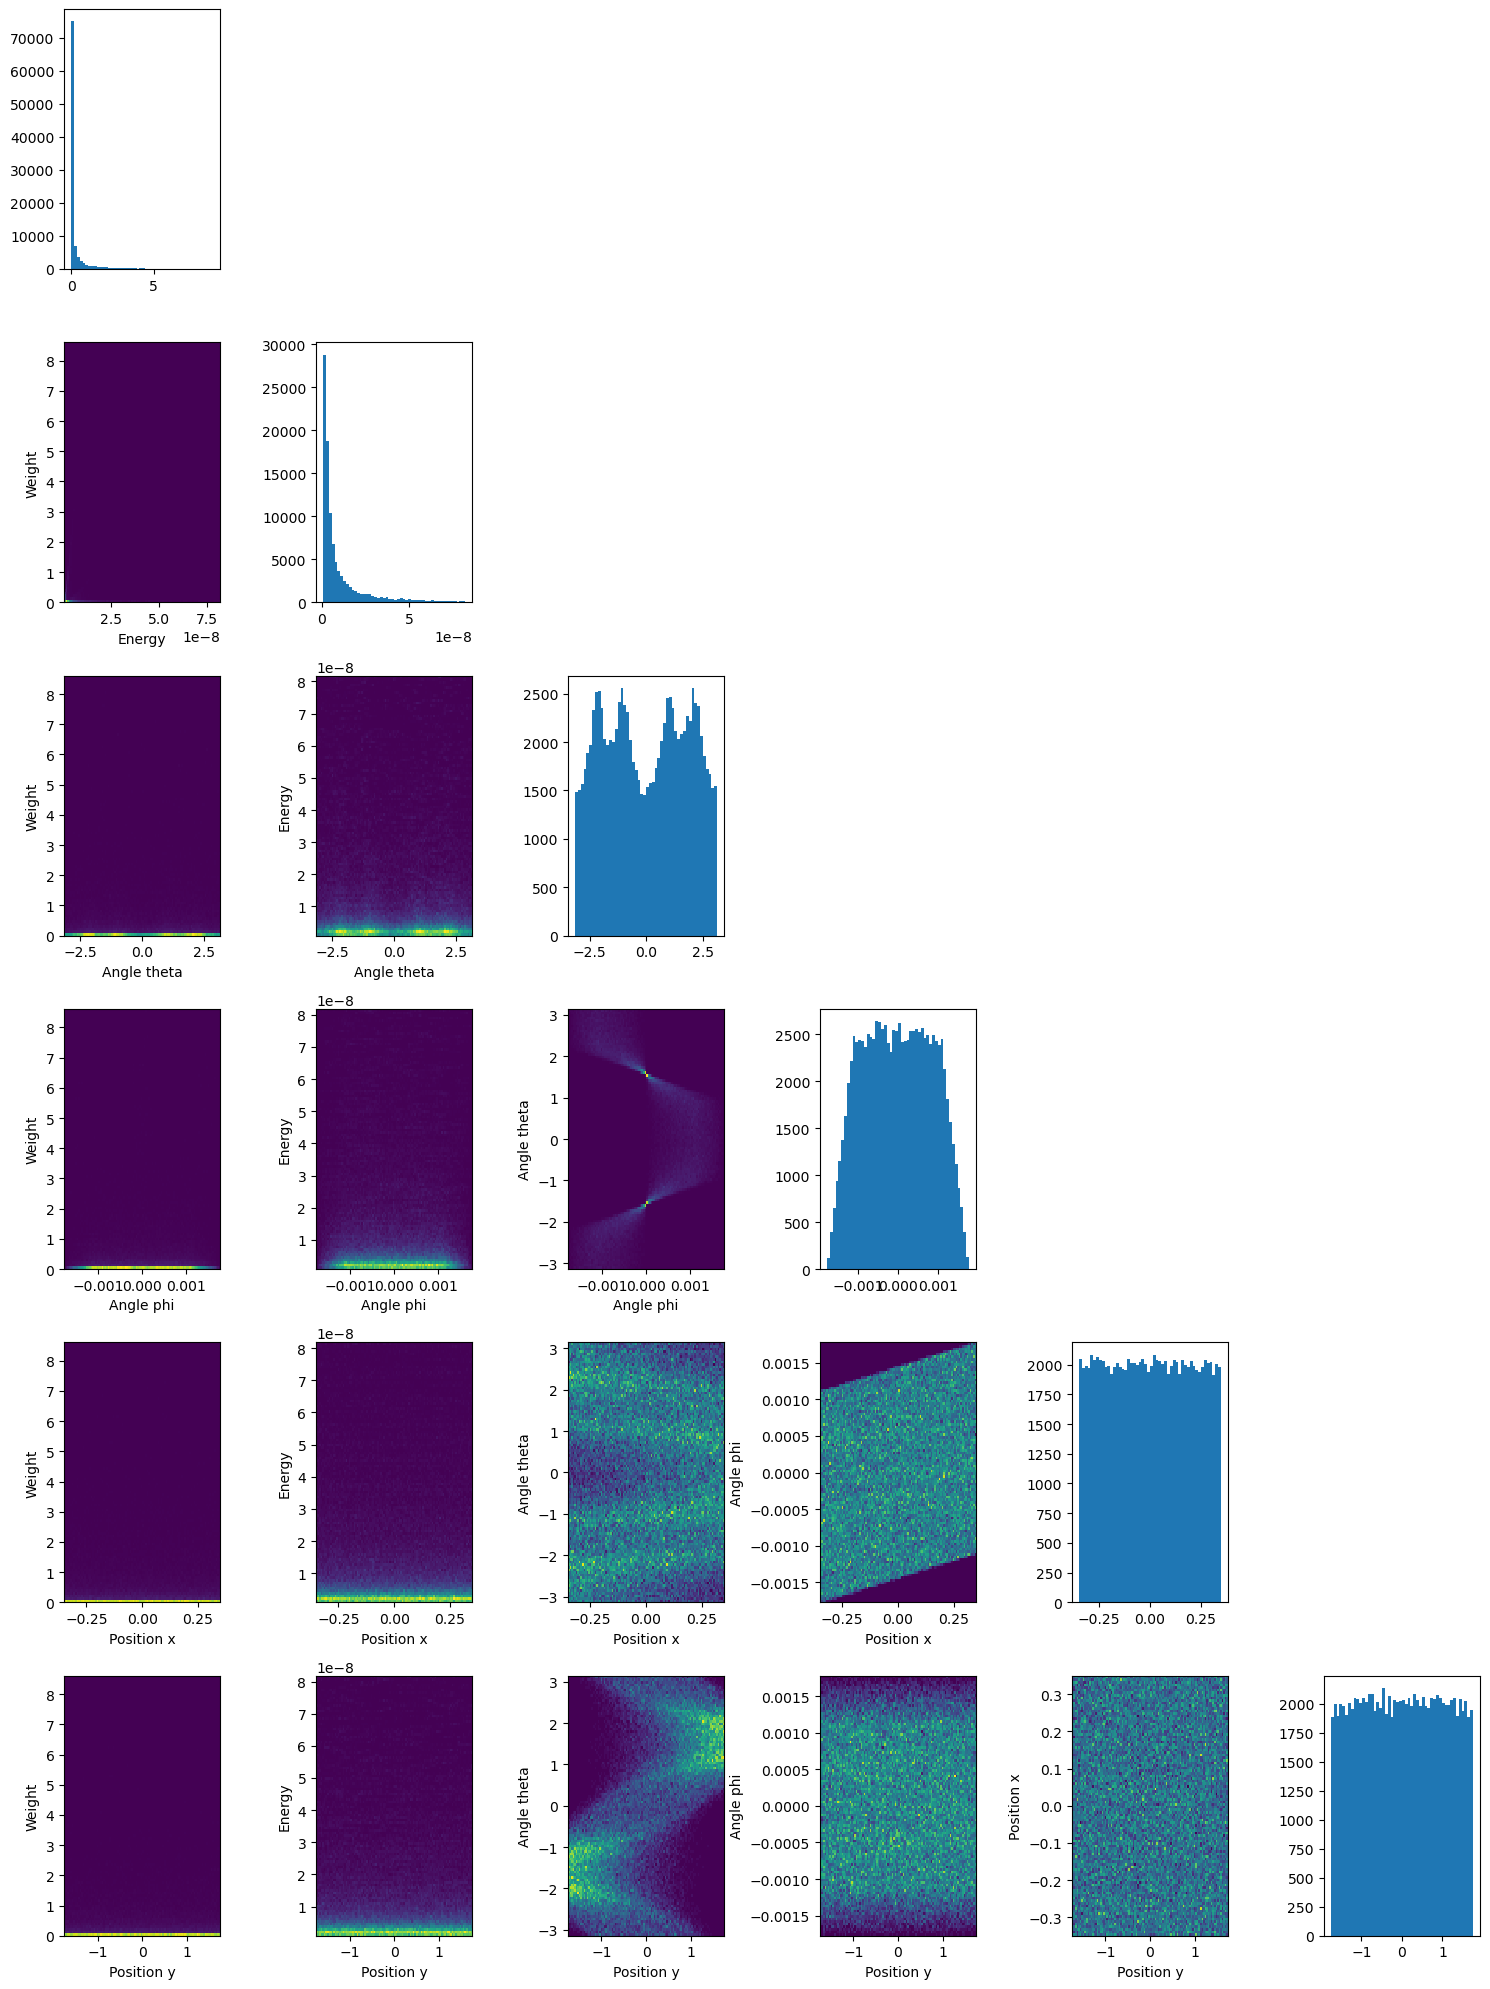

In [8]:
fig, ax = plt.subplots(ncols=6, nrows=6, figsize=(15,20))
for i in range(6):
    for j in range(6):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i and i!= 7:
            ax[i,j].hist(data[:,i], bins=50)
            continue
        ax[i,j].hist2d(data[:,i], data[:,j], bins=100)
        ax[i,j].set(xlabel=labels[i], ylabel=labels[j])
plt.tight_layout()

In [ ]:
# First, build autoencoder to a latent space with 1 dimension
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(8, 30),
            nn.ReLU(),
            nn.Linear(30, 50),
            nn.ReLU(),
            nn.Linear(50, 25),
            nn.ReLU(),
            nn.Linear(25, 8),
            nn.ReLU(),
            nn.Linear(8, 5),
            nn.ReLU(),
            nn.Linear(5, 3),
            nn.ReLU(),
            nn.Linear(3, 1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 3),
            nn.ReLU(),
            nn.Linear(3, 5),
            nn.ReLU(),
            nn.Linear(5, 8),
            nn.ReLU(),
            nn.Linear(8, 25),
            nn.ReLU(),
            nn.Linear(25, 50),
            nn.ReLU(),
            nn.Linear(50, 30),
            nn.ReLU(),
            nn.Linear(30, 8),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
model = AE()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

In [137]:
model.to(device)
epochs = 5
outputs = []
losses = []
data = data.to(device)
for epoch in range(epochs):
    for sample in data:
        reconstructed = model(sample)
        loss = loss_function(reconstructed,sample )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    outputs.append((epoch, sample, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 1/5, Loss: 4558690.000000


KeyboardInterrupt: 

In [139]:
model.encoder(data[10:10])

tensor([], device='mps:0', size=(0, 1), grad_fn=<LinearBackward0>)

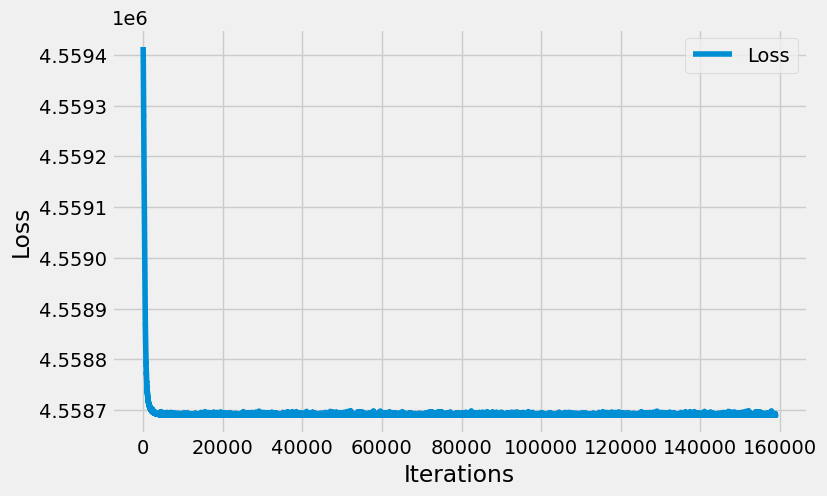

In [138]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()